In [1]:
import os
import scanpy
import treeclust.scanpy as tcsc

from treeclust.pipelines import PipelineBootstrapper
from treeclust.decomposition import PCA
from sklearn.model_selection import ShuffleSplit

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import moscot

/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
files = (
    ("48h", "72h"),
    ("72h", "96h"),
    ("96h", "120h"),
    ("120h", "144h"),
)

/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2025-12-30 15:13:44,033 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-30 15:13:44,422 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-30 15:13:44,437 - harmonypy - INFO - Iteration 1 of 10
2025-12-30 15:13:44,984 - harmonypy - INFO - Iteration 2 of 10
2025-12-30 15:13:45,507 - harmonypy - INFO - Converged after 2 iterations


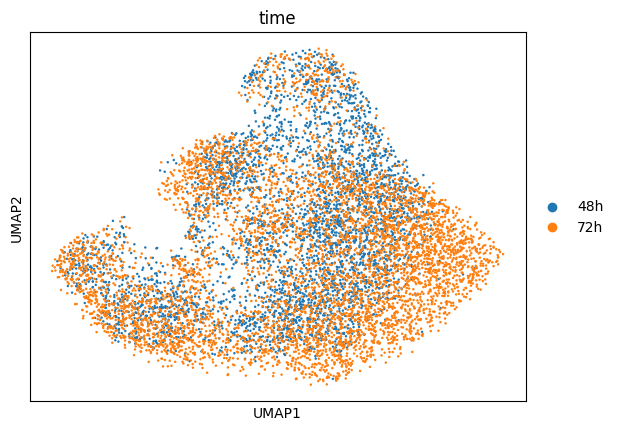

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(3873, 5637)].                                  
WARNING  Solver did not converge                                                                                   


/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2025-12-30 15:15:04,244 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-30 15:15:04,803 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-30 15:15:04,825 - harmonypy - INFO - Iteration 1 of 10
2025-12-30 15:15:05,760 - harmonypy - INFO - Iteration 2 of 10
2025-12-30 15:15:06,662 - harmonypy - INFO - Converged after 2 iterations


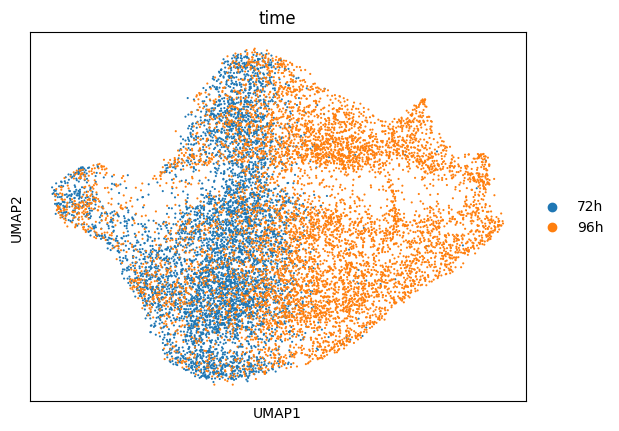

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(5637, 7148)].                                  
WARNING  Solver did not converge                                                                                   


/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
2025-12-30 15:17:20,499 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-30 15:17:21,367 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-30 15:17:21,399 - harmonypy - INFO - Iteration 1 of 10
2025-12-30 15:17:22,927 - harmonypy - INFO - Iteration 2 of 10
2025-12-30 15:17:24,394 - harmonypy - INFO - Converged after 2 iterations


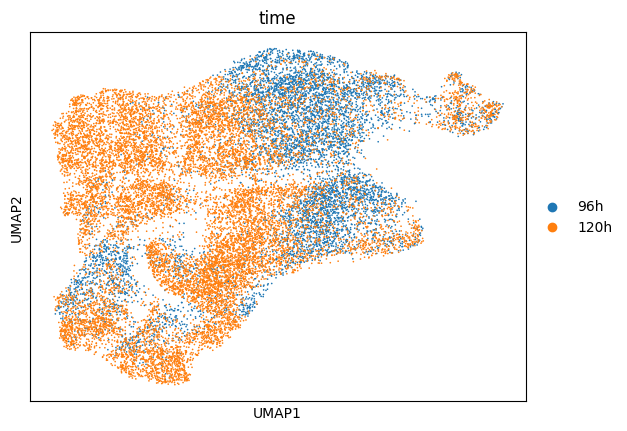

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(7148, 13764)].                                 
WARNING  Solver did not converge                                                                                   


/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gatocor/miniforge3/envs/treeclust-scanpy/lib/python3.13/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2025-12-30 15:22:40,288 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-30 15:22:42,248 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-30 15:22:42,327 - harmonypy - INFO - Iteration 1 of 10
2025-12-30 15:22:44,989 - harmonypy - INFO - Iteration 2 of 10
2025-12-30 15:22:47,681 - harmonypy - INFO - Iteration 3 of 10
2025-12-30 1

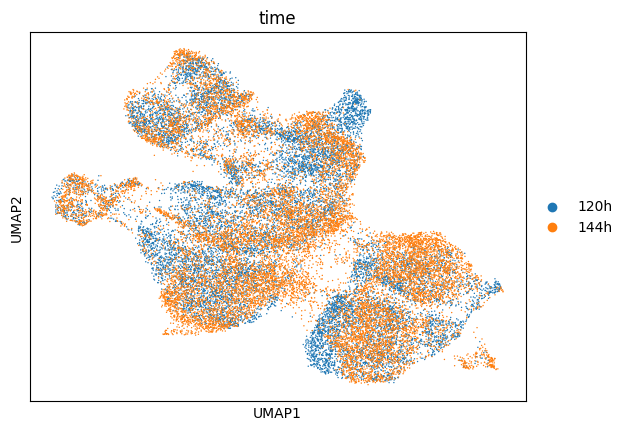

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(13764, 15197)].                                
WARNING  Solver did not converge                                                                                   


In [24]:
for t1, t2 in files:

    adata1 = scanpy.read_h5ad(f"data/dias_{t1}_EM_processed_annotated_plotting_curated_annotation.h5ad")
    adata1.obs["time"] = t1
    adata1.var_names = adata1.var["Gene"].values.astype(str)
    adata1.var_names_make_unique()
    adata2 = scanpy.read_h5ad(f"data/dias_{t2}_EM_processed_annotated_plotting_curated_annotation.h5ad")
    adata2.obs["time"] = t2
    adata2.var_names = adata2.var["Gene"].values.astype(str)
    adata2.var_names_make_unique()
    adata = scanpy.concat([adata1, adata2])

    adata.obs["time_numeric"] = adata.obs["time"].apply(lambda x: int(x.replace("h","")))

    scanpy.pp.highly_variable_genes(
        adata
    )

    scanpy.pp.pca(
        adata,
        n_comps=30,
    )

    scanpy.external.pp.harmony_integrate(
        adata,
        key="time",
    )

    scanpy.pp.neighbors(adata, use_rep="X_pca_harmony")

    scanpy.tl.umap(adata)

    fig, ax = plt.subplots()
    scanpy.pl.umap(adata, color="time", ax=ax)
    fig.savefig(f"figures/ot_umap_plot_{t1}_{t2}.png")

    problem = moscot.problems.time.TemporalProblem(adata)

    problem.prepare(time_key="time_numeric", joint_attr="X_pca_harmony")

    problem.score_genes_for_marginals(
        gene_set_proliferation="mouse", gene_set_apoptosis="mouse"
    )

    problem.solve()

    for annotation in ["annotation_cell_type", "annotation_hard"]:
        problem.sankey(int(t1.replace("h","")),int(t2.replace("h","")), annotation, annotation)
        matrix_df = adata.uns["moscot_results"]["sankey"]["sankey"]["transition_matrices"][0]
        os.makedirs(f"sankey/{annotation}", exist_ok=True)
        matrix_df.to_csv(f"sankey/{annotation}/ot_{t1}_{t2}.csv")